In [118]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [119]:
df=pd.read_csv('/content/cleaned_df.csv', index_col=0)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0.0,1.0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0.0,2.0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0.0,2.0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0.0,2.0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0.0,2.0,1


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 35.5 KB


In [121]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,245.194719,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.663366,2.326733,0.544554
std,9.082101,0.466011,1.032052,17.538143,48.488324,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,0.934375,0.583020,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,417.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [122]:
df['target'].value_counts()

,count
target,
1,165
0,138


In [123]:
y=df.target
X=df.drop('target', axis=1)
X_train, X_test, y_train, Y_test = train_test_split(X,y, test_size=0.30, )
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [124]:
df.shape

(303, 14)

In [125]:
X_train

array([[-0.18935365,  0.67975655,  0.95523484, ...,  0.9908498 ,
         2.38986091, -0.56422962],
       [ 0.80867607,  0.67975655, -0.92857712, ..., -0.65024518,
         1.35164264,  1.16934545],
       [-1.18738336,  0.67975655, -0.92857712, ..., -2.29134015,
        -0.72479388, -2.29780469],
       ...,
       [ 0.58689169, -1.47111492, -0.92857712, ..., -0.65024518,
         1.35164264,  1.16934545],
       [ 0.36510731, -1.47111492, -0.92857712, ..., -0.65024518,
        -0.72479388, -0.56422962],
       [ 0.69778388,  0.67975655,  1.89714082, ..., -0.65024518,
         1.35164264, -0.56422962]])

In [126]:
X_train[0]

array([-0.18935365,  0.67975655,  0.95523484, -0.10069253,  0.0064204 ,
        2.56347978, -0.97496464,  1.03638163, -0.65759595, -0.92480495,
        0.9908498 ,  2.38986091, -0.56422962])

#Baseline model

In [127]:
from sklearn.dummy import DummyClassifier

In [128]:
DC=DummyClassifier()
DC.fit(X_train, y_train)
DC.predict(X_test)
DC.score(X_test, Y_test)

0.5384615384615384

#Logestic Regression

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [130]:
LR=LogisticRegression()
LR.fit(X_train, y_train)
y_pred=LR.predict(X_test)
lr_accuracy=accuracy_score(Y_test, y_pred)
print(lr_accuracy)
lr_cm=confusion_matrix(Y_test, y_pred)
print(lr_cm)
lr_cr=classification_report(Y_test, y_pred)
print(lr_cr)


0.8791208791208791
[[34  8]
 [ 3 46]]
              precision    recall  f1-score   support

           0       0.92      0.81      0.86        42
           1       0.85      0.94      0.89        49

    accuracy                           0.88        91
   macro avg       0.89      0.87      0.88        91
weighted avg       0.88      0.88      0.88        91



In [131]:
from sklearn.metrics import cohen_kappa_score

# Calculate Cohen's Kappa
kappa = cohen_kappa_score(Y_test, y_pred)
print(f"Cohen's Kappa: {kappa}")


Cohen's Kappa: 0.7547169811320755


#Decision Tree

In [132]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

In [133]:
tree=DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred=tree.predict(X_test)
DTC_accuracy= accuracy_score(Y_test, y_pred)
print(f'DTC_accuracy: {DTC_accuracy}')
tree_f1_score=f1_score(Y_test, y_pred)
print(f'tree_f1_score: {tree_f1_score}')


DTC_accuracy: 0.7472527472527473
tree_f1_score: 0.7676767676767676


In [134]:
DTC_cm=confusion_matrix(Y_test, y_pred)
print(DTC_cm)
DTC_cr=classification_report(Y_test, y_pred)
print(DTC_cr)

[[30 12]
 [11 38]]
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        42
           1       0.76      0.78      0.77        49

    accuracy                           0.75        91
   macro avg       0.75      0.74      0.75        91
weighted avg       0.75      0.75      0.75        91



[Text(0.530448717948718, 0.95, 'cp <= -0.458\ngini = 0.496\nsamples = 212\nvalue = [96, 116]'),
 Text(0.26282051282051283, 0.85, 'ca <= -0.206\ngini = 0.413\nsamples = 103\nvalue = [73.0, 30.0]'),
 Text(0.3966346153846154, 0.8999999999999999, 'True  '),
 Text(0.15384615384615385, 0.75, 'thal <= 0.303\ngini = 0.498\nsamples = 47\nvalue = [22, 25]'),
 Text(0.10256410256410256, 0.65, 'chol <= 1.632\ngini = 0.32\nsamples = 25\nvalue = [5, 20]'),
 Text(0.07692307692307693, 0.55, 'chol <= -0.806\ngini = 0.227\nsamples = 23\nvalue = [3, 20]'),
 Text(0.05128205128205128, 0.45, 'exang <= 0.432\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.02564102564102564, 0.35, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.07692307692307693, 0.35, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.10256410256410256, 0.45, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.1282051282051282, 0.55, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.20512820512820512, 0.65, 'oldpeak <= -0.346\ngi

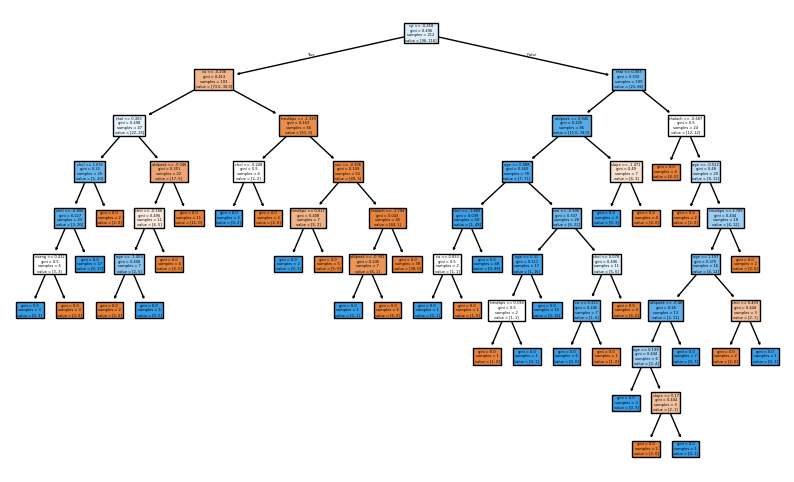

In [135]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
plot_tree(tree, filled=True, feature_names=df.columns )

#Random Forest

In [136]:
from sklearn.ensemble import RandomForestClassifier

In [137]:
rfc=RandomForestClassifier()
model=rfc.fit(X_train, y_train)
y_pred=model.predict(X_test)

rfc_accuracy=accuracy_score(Y_test, y_pred)
print(f'rfc_accuracy: {rfc_accuracy}')
rfc_f1_score=f1_score(Y_test, y_pred)
print(f'rfc_f1_score: {rfc_f1_score}')

rfc_accuracy: 0.8681318681318682
rfc_f1_score: 0.8823529411764706


In [138]:
cm=confusion_matrix(Y_test, y_pred)
print(cm)
cr=classification_report(Y_test, y_pred)
print(cr)

[[34  8]
 [ 4 45]]
              precision    recall  f1-score   support

           0       0.89      0.81      0.85        42
           1       0.85      0.92      0.88        49

    accuracy                           0.87        91
   macro avg       0.87      0.86      0.87        91
weighted avg       0.87      0.87      0.87        91



#Naive bayes

In [139]:
from sklearn.naive_bayes import GaussianNB

In [140]:
nb=GaussianNB()
nb.fit(X_train, y_train)
y_pred=nb.predict(X_test)

nb_accuracy=accuracy_score(Y_test, y_pred)
print(f'nb_accuracy: {nb_accuracy}')
nb_f1_score=f1_score(Y_test, y_pred)
print(f'nb_f1_score: {nb_f1_score}')

nb_accuracy: 0.8681318681318682
nb_f1_score: 0.8846153846153846


In [141]:
cm=confusion_matrix(Y_test, y_pred)
print(cm)
cr=classification_report(Y_test, y_pred)
print(cr)

[[33  9]
 [ 3 46]]
              precision    recall  f1-score   support

           0       0.92      0.79      0.85        42
           1       0.84      0.94      0.88        49

    accuracy                           0.87        91
   macro avg       0.88      0.86      0.87        91
weighted avg       0.87      0.87      0.87        91



In [145]:
model_per=pd.DataFrame({
    'Model':['Dummy classifier','Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy':[DC.score(X_test, Y_test), lr_accuracy, DTC_accuracy, rfc_accuracy, nb_accuracy],

})

In [146]:
model_per

,Model,Accuracy
0,Dummy classifier,0.538462
1,Logistic Regression,0.879121
2,Decision Tree,0.747253
3,Random Forest,0.868132
4,Naive Bayes,0.868132
